In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import mlflow
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
import json

mlflow.set_tracking_uri("file:./mlruns")

In [2]:
data = pd.read_csv("..\DataCleaning\cleaned_data.csv", parse_dates=['date'])


In [3]:
data = data.sort_values('date')

In [4]:
data['date'].max()

Timestamp('2025-10-26 00:00:00')

In [5]:
data.shape

(19193, 35)

In [6]:
data.head()

,date,hospital_id,ward_code,wait_per_triage,age,bed_impact_score,arrival_source_ambulance,arrival_source_referral,arrival_source_self,arrival_source_transfer,...,overflow_lag1,overflow_lag7,discharges_lag1,discharges_lag7,admission_rate_per_bed_lag1,admission_rate_per_bed_lag7,avg_wait_minutes_lag1,avg_wait_minutes_lag7,occupancy_rate_lag1,occupancy_rate_lag7
0,2022-11-02,1,MED,97.837037,54.333333,10.000,3,0,5,1,...,29.0,19.0,30.0,11.0,1.833,1.000,257.0,147.0,1.0,1.000
1,2022-11-03,1,ICU,77.333333,50.125000,20.250,1,0,7,0,...,4.0,1.0,8.0,7.0,0.450,0.650,195.0,89.0,1.0,0.935
2,2022-11-03,1,ICU,77.333333,50.125000,20.250,1,0,7,0,...,9.0,7.0,6.0,6.0,0.600,0.600,276.0,197.0,1.0,1.000
3,2022-11-03,1,MED,49.666667,65.333333,10.000,5,0,3,1,...,42.0,26.0,23.0,17.0,1.280,1.700,297.0,219.0,1.0,1.000
23,2022-11-04,5,SURG,39.000000,55.875000,13.875,0,1,7,0,...,9.0,2.0,17.0,8.0,0.500,0.625,93.0,123.0,1.0,0.935


In [7]:
data.columns

Index(['date', 'hospital_id', 'ward_code', 'wait_per_triage', 'age',
       'bed_impact_score', 'arrival_source_ambulance',
       'arrival_source_referral', 'arrival_source_self',
       'arrival_source_transfer', 'outcome_death', 'outcome_discharged',
       'outcome_readmit_30d', 'outcome_transferred', 'outcome_unknown',
       'sex_F', 'sex_M', 'sex_X', 'base_beds', 'effective_capacity',
       'admissions', 'staffing_index', 'discharge_rate_per_bed',
       'occupancy_lag1', 'occupancy_lag7', 'overflow_lag1', 'overflow_lag7',
       'discharges_lag1', 'discharges_lag7', 'admission_rate_per_bed_lag1',
       'admission_rate_per_bed_lag7', 'avg_wait_minutes_lag1',
       'avg_wait_minutes_lag7', 'occupancy_rate_lag1', 'occupancy_rate_lag7'],
      dtype='object')

### Split the data

In [7]:
train_size = int(len(data) * 0.8)

# train_data = data.iloc[:train_size]
# test_data = data.iloc[train_size:]

#### Feature selection with mututal info

In [8]:
mi_data = data.drop(columns=['date', 'hospital_id', 'ward_code'])

<Axes: ylabel='Feature'>

<Figure size 1000x800 with 0 Axes>

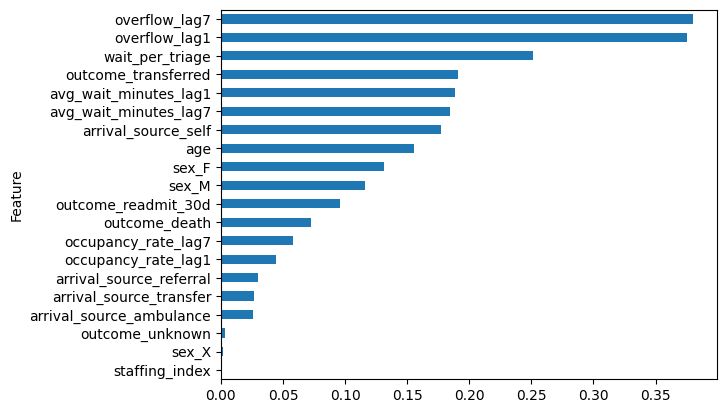

In [9]:
target = mi_data['admissions']
var = mi_data.drop(columns=['admissions'])

from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(var, target, random_state=42)
mi_df = pd.DataFrame(
    {
        'Feature': var.columns,
        'MI_Score': mi_scores
    }
).sort_values('MI_Score', ascending=True)

plt.figure(figsize=(10, 8))
mi_df.head(20).plot(x='Feature', y='MI_Score', kind='barh', legend=False)

### Split data with external features sampled on daily basis

In [10]:
data.columns

Index(['date', 'hospital_id', 'ward_code', 'wait_per_triage', 'age',
       'bed_impact_score', 'arrival_source_ambulance',
       'arrival_source_referral', 'arrival_source_self',
       'arrival_source_transfer', 'outcome_death', 'outcome_discharged',
       'outcome_readmit_30d', 'outcome_transferred', 'outcome_unknown',
       'sex_F', 'sex_M', 'sex_X', 'base_beds', 'effective_capacity',
       'admissions', 'staffing_index', 'discharge_rate_per_bed',
       'occupancy_lag1', 'occupancy_lag7', 'overflow_lag1', 'overflow_lag7',
       'discharges_lag1', 'discharges_lag7', 'admission_rate_per_bed_lag1',
       'admission_rate_per_bed_lag7', 'avg_wait_minutes_lag1',
       'avg_wait_minutes_lag7', 'occupancy_rate_lag1', 'occupancy_rate_lag7'],
      dtype='object')

In [11]:
top_features = mi_df['Feature'].head(20).to_list()

data = pd.get_dummies(data, columns=['ward_code'], drop_first=False)

bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

ward_cols = [col for col in data.columns if col.startswith('ward_code_ ')]

exog_features = top_features + ['hospital_id'] + ward_cols


In [12]:

print(train_size)

data = data.set_index('date')

X_train = data[exog_features].iloc[:train_size]
y_train = data['admissions'].iloc[:train_size]

X_test = data[exog_features].iloc[train_size:]
y_test = data['admissions'].iloc[train_size:]

15354


In [13]:
print(len(X_train), len(y_train), len(X_test), len(y_test))

15354 15354 3839 3839


### Split data with external features sampled on a weekly basis

In [14]:
data.columns

Index(['hospital_id', 'wait_per_triage', 'age', 'bed_impact_score',
       'arrival_source_ambulance', 'arrival_source_referral',
       'arrival_source_self', 'arrival_source_transfer', 'outcome_death',
       'outcome_discharged', 'outcome_readmit_30d', 'outcome_transferred',
       'outcome_unknown', 'sex_F', 'sex_M', 'sex_X', 'base_beds',
       'effective_capacity', 'admissions', 'staffing_index',
       'discharge_rate_per_bed', 'occupancy_lag1', 'occupancy_lag7',
       'overflow_lag1', 'overflow_lag7', 'discharges_lag1', 'discharges_lag7',
       'admission_rate_per_bed_lag1', 'admission_rate_per_bed_lag7',
       'avg_wait_minutes_lag1', 'avg_wait_minutes_lag7', 'occupancy_rate_lag1',
       'occupancy_rate_lag7', 'ward_code_ED', 'ward_code_ICU', 'ward_code_MED',
       'ward_code_SURCG', 'ward_code_SURG'],
      dtype='object')

In [15]:
top_features = mi_df['Feature'].head(20).to_list()

if 'ward_code' in data.columns:
    data = pd.get_dummies(data, columns=['ward_code'], drop_first=False)

bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

ward_cols = [col for col in data.columns if col.startswith('ward_code_')]

exog_features = top_features + ['hospital_id'] + ward_cols

print("ward_code present:", 'ward_code' in data.columns)
print("ward dummies:", len(ward_cols))


if 'date' in data.columns:
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date')
else:
    print("date not in columns — index name:", data.index.name)

weekly_target = data['admissions'].resample('W').mean()
weekly_exog = data[exog_features].resample('W').mean()

train_size = int(len(weekly_target) * 0.8)

X_train = weekly_exog.iloc[:train_size]
y_train = weekly_target.iloc[:train_size]

X_test = weekly_exog.iloc[train_size:]
y_test = weekly_target.iloc[train_size:]

print(train_size)

ward_code present: False
ward dummies: 5
date not in columns — index name: date
124


In [16]:
print(len(X_train), len(y_train), len(X_test), len(y_test))

124 124 32 32


### Train SARIMAX using MLflow

In [17]:
mlflow.set_experiment("Hospital Admissions Forecasting")

2026/01/26 02:55:02 INFO mlflow.tracking.fluent: Experiment with name 'Hospital Admissions Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/Edwina/Documents/Amdari_files/ds_projects/MedOptix/model/mlruns/636630878536302458', creation_time=1769396102752, experiment_id='636630878536302458', last_update_time=1769396102752, lifecycle_stage='active', name='Hospital Admissions Forecasting', tags={}>

length of y_test: 32
sarimax_mae: 0.47729889638632617
sarimax_rmse: 0.5717049647860183
sarimax_r2: 0.8759732010780367


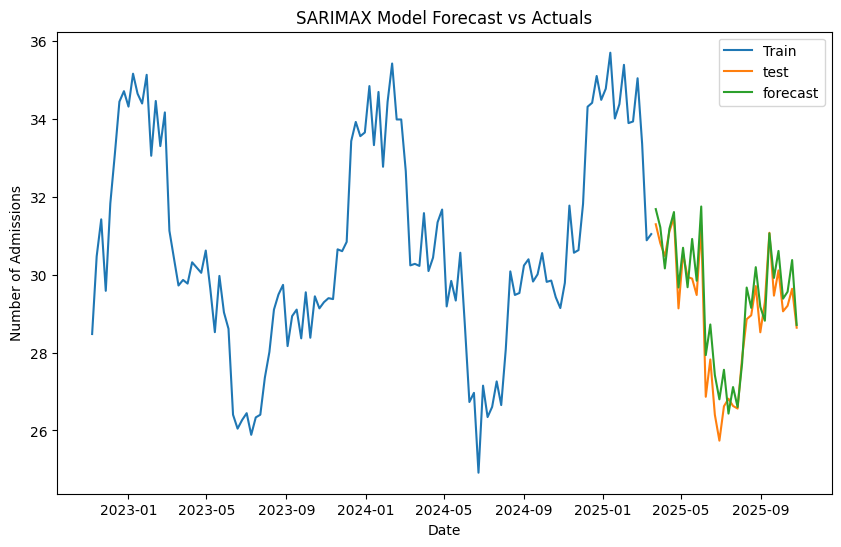

In [18]:
with mlflow.start_run(run_name="SARIMAX model"):
    sarimax_model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=(1, 1, 2),
        seasonal_order=(2, 0, 2, 7)
    ).fit(disp=False)

    print("length of y_test:", len(y_test))

    sarimax_forecast = sarimax_model.forecast(steps=len(y_test), exog=X_test)

    sarimax_mae = mean_absolute_error(y_test, sarimax_forecast)
    sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_forecast))
    sarimax_r2 = r2_score(y_test, sarimax_forecast)

    print("sarimax_mae:", sarimax_mae)
    print("sarimax_rmse:", sarimax_rmse)
    print("sarimax_r2:", sarimax_r2)

    mlflow.log_param("order", (1, 1, 2))
    mlflow.log_param("seasonal_order", (2, 0, 2, 7))
    mlflow.log_param("exogenous_features", exog_features)

    mlflow.log_metric("MAE", sarimax_mae)
    mlflow.log_metric("RMSE", sarimax_rmse)
    mlflow.log_metric("R2_Score", sarimax_r2)

    with open("sarimax_model.pkl", "wb") as f:
        pickle.dump(sarimax_model, f)
    
    with open("sarimax_schema.json", "w") as f:
        json.dump(exog_features, f)

    mlflow.log_artifact("sarimax_model.pkl")

    plt.figure(figsize=(10, 6))
    plt.plot(y_train.index, y_train, label = 'Train')
    plt.plot(y_test.index, y_test, label ='test')
    plt.plot(y_test.index, sarimax_forecast, label = 'forecast')
    plt.legend()
    plt.title("SARIMAX Model Forecast vs Actuals")
    plt.xlabel("Date")
    plt.ylabel("Number of Admissions")
    plt.savefig("sarimax_forecast.png")

    mlflow.log_artifact("sarimax_forecast.png")
    plt.show()

### Hyper Parameter Tuning using Auto ARIMA

In [19]:
from pmdarima import auto_arima

model = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=7,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    
    stepwise=False, 
    random=True,  
    n_fits=30,   
    random_state=42 
)

print(model.summary())
print(f"Best order: {model.order}")
print(f"Best seasonal_order: {model.seasonal_order}")

 ARIMA(2,0,3)(0,0,0)[7] intercept   : AIC=387.620, Time=0.49 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=599.438, Time=0.01 sec
 ARIMA(2,0,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=574.554, Time=0.47 sec
 ARIMA(1,0,3)(0,0,1)[7] intercept   : AIC=390.283, Time=0.36 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=496.947, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[7] intercept   : AIC=458.145, Time=0.08 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(2,0,1)(0,0,1)[7] intercept   : AIC=391.017, Time=0.23 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=393.096, Time=0.68 sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=393.750, Time=0.83 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=379.301, Time=0.62 sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(2,0,1)(0,0,0)[7] intercept   : AIC=389